In [8]:
# Perceptron
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
# Load the iris dataset
iris = load_iris(return_X_y=True, as_frame=True)
data = iris[0]
target = iris[1]
df = pd.concat([data, target], axis=1)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [9]:
df = df.iloc[:100, [0, 2, -1]]
df

,sepal length (cm),petal length (cm),target
0,5.1,1.4,0
1,4.9,1.4,0
2,4.7,1.3,0
3,4.6,1.5,0
4,5.0,1.4,0
...,...,...,...
95,5.7,4.2,1
96,5.7,4.2,1
97,6.2,4.3,1
98,5.1,3.0,1


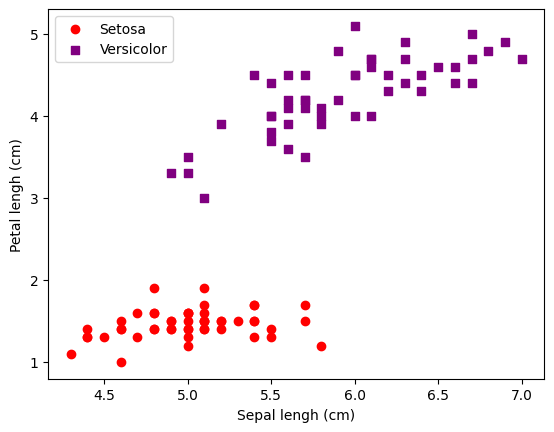

In [10]:
x = df.iloc[:, [0, 1]].values # sepal length | petal length
y = df.iloc[:, -1].values  # target

# الرسم 
plt.scatter(x[:50, 0], x[:50, 1], color='red', marker='o', label='Setosa')
plt.scatter(x[50:100, 0], x[50:100, 1], color='purple', marker='s', label='Versicolor')
plt.legend(loc='upper left')
plt.xlabel("Sepal lengh (cm)")
plt.ylabel("Petal lengh (cm)")
plt.show()

In [11]:
# split the data !
X_train, y_train, X_test, y_test = train_test_split(x , y, random_state=123, test_size=0.2)

In [12]:
# Logistic Reression !!!

from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
x = iris.data[:100, :2]
y = iris.target[:100]

X_train, X_test, y_train, y_test = train_test_split(x , y, test_size=0.2, random_state=0)

In [13]:
model = LogisticRegression()

model.fit(X_train, y_train)

print(f"Coeff : {model.coef_}")
print(f"Inter : {model.intercept_}")

Coeff : [[ 2.85548516 -2.79090819]]
Inter : [-6.85046879]


In [14]:
len(X_train), len(X_test) # عشرين بالمئة راحت للتاست و ثمانين راحت لترين لانو تاست سايز يساوي صفر فاصل إثنين

(80, 20)

In [15]:
y_pred = model.predict(X_test)

In [16]:
y_prob = model.predict_proba(X_test)

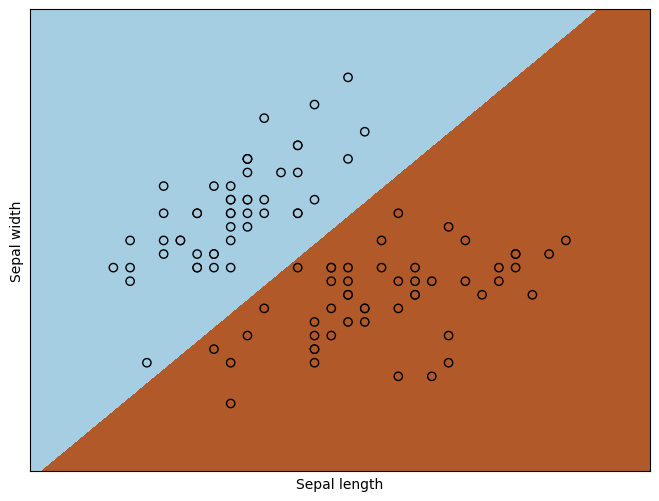

In [17]:
x_min, x_max = x[:, 0].min() - .5, x[:, 0].max() + .5
y_min, y_max = x[:, 1].min() - .5, x[:, 1].max() + .5
h = .001  # step size in the mesh
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.figure(1, figsize=(8, 6))
plt.pcolormesh(xx, yy, Z, cmap=plt.cm.Paired)

# Plot also the training points
plt.scatter(x[:, 0], x[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')

plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xticks(())
plt.yticks(())

plt.show()

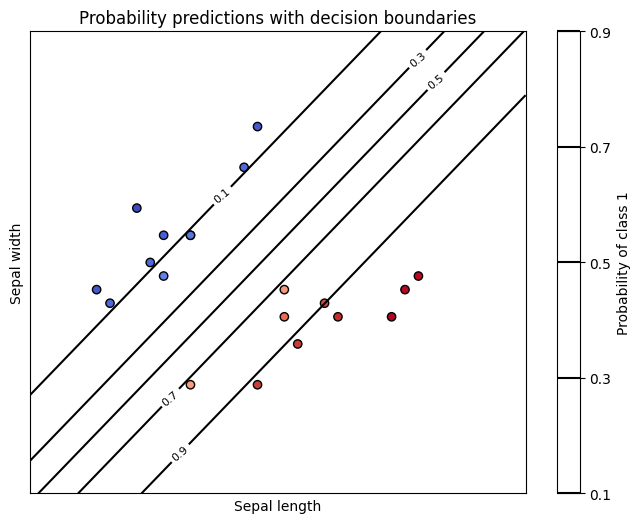

In [18]:
# Step 11 - Plotting the probabilities with contour lines
plt.figure(2, figsize=(8, 6))

# Probabilities of class 1 for each point in the grid
Z_prob = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z_prob = Z_prob.reshape(xx.shape)

# Scatter plot of the test data, colored by the probability of class 1
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_prob[:, 1], edgecolors='k', cmap=plt.cm.coolwarm)

# Contour plot for levels of probabilities
contour = plt.contour(xx, yy, Z_prob, levels=[0.1, 0.3, 0.5, 0.7, 0.9], colors='k')
plt.clabel(contour, inline=True, fontsize=8)

plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.colorbar(label='Probability of class 1')
plt.title('Probability predictions with decision boundaries')

plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.xticks(())
plt.yticks(())

plt.show()

In [19]:
from sklearn.metrics import accuracy_score, confusion_matrix

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy : {accuracy}')

conf_mat = confusion_matrix(y_test, y_pred)
print(f'conf_mat : \n{conf_mat}')

Accuracy : 1.0
conf_mat : 
[[10  0]
 [ 0 10]]


In [20]:
# Polynomial regression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [21]:
np.random.seed(42)
x = np.linspace(-np.pi, np.pi, 100)
y = np.cos(x) + np.random.normal(0, 0.1, x.shape)

df = pd.DataFrame({'X':x,
                   'Y':y})

df.head()

,X,Y
0,-3.141593,-0.950329
1,-3.078126,-1.011813
2,-3.014660,-0.927186
3,-2.951193,-0.829626
4,-2.887727,-0.991364


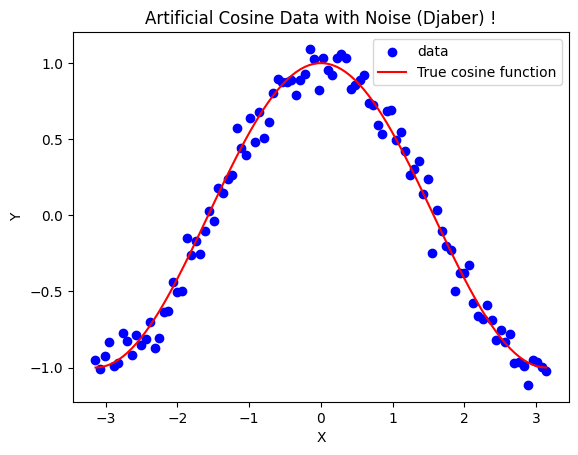

In [22]:
plt.scatter(df['X'], df['Y'], c='b', label="data")
plt.plot(x, np.cos(x), c='r', label="True cosine function")
plt.xlabel('X')
plt.ylabel('Y')
plt.title("Artificial Cosine Data with Noise (Djaber) !")
plt.legend()
plt.show()

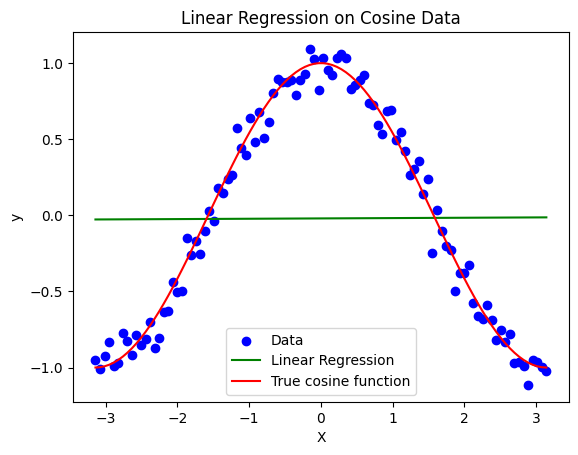

In [23]:
model = LinearRegression()
model.fit(x.reshape(-1,1) ,y)
y_pred = model.predict(x.reshape(-1,1))

# Plotting the results
plt.scatter(x, y, c='b', label="Data")
plt.plot(x, y_pred, c='g', label="Linear Regression")
plt.plot(x, np.cos(x), c='r', label="True cosine function")
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression on Cosine Data')
plt.legend()
plt.show()
# غير مناسب لانه رسم دالة خطية غير مناسبة لهذا المودل ؟؟

In [24]:
df['bias'] = 1
df['X^2'] = df['X'] ** 2
df['X^3'] = df['X'] ** 3
df['X^4'] = df['X'] ** 4
df['X^5'] = df['X'] ** 5
df['X^6'] = df['X'] ** 6

df.head()

,X,Y,bias,X^2,X^3,X^4,X^5,X^6
0,-3.141593,-0.950329,1,9.869604,-31.006277,97.409091,-306.019685,961.389194
1,-3.078126,-1.011813,1,9.474861,-29.164816,89.772982,-276.332561,850.586478
2,-3.014660,-0.927186,1,9.088173,-27.397747,82.594881,-248.995453,750.636538
3,-2.951193,-0.829626,1,8.709541,-25.703536,75.856099,-223.865997,660.671785
4,-2.887727,-0.991364,1,8.338965,-24.080650,69.538334,-200.807695,579.877720


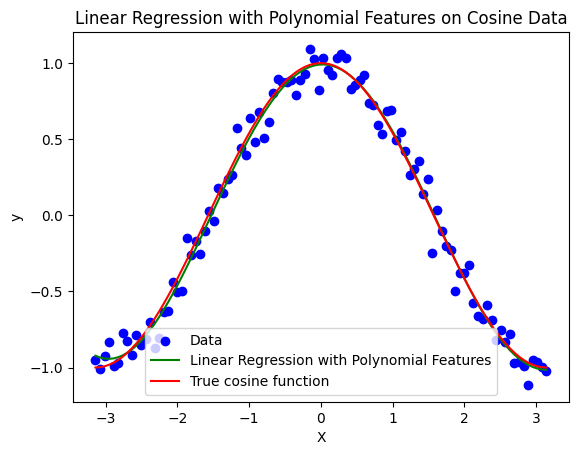

In [25]:
X_poly = df[['X', 'X^2', 'X^3', 'X^4', 'X^5', 'X^6', 'bias']].values

lin_reg_poly = LinearRegression()
lin_reg_poly.fit(X_poly, y)

y_pred_poly = lin_reg_poly.predict(X_poly)

# Plotting the results
plt.scatter(x, y, c='b', label="Data")
plt.plot(x, y_pred_poly, c='g', label="Linear Regression with Polynomial Features")
plt.plot(x, np.cos(x), c='r', label="True cosine function")
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression with Polynomial Features on Cosine Data')
plt.legend()
plt.show()

In [26]:
# Polynomial Regression - scikit learn || بالعربية || Machine Learning #19
from sklearn.preprocessing import PolynomialFeatures

np.random.seed(42)
x = np.linspace(-np.pi, np.pi, 100)
y = np.cos(x) + np.random.normal(0, 0.1, x.shape)

df = pd.DataFrame({'X':x,
                   'Y':y})
x = x.reshape(-1,1)
poly_tran = PolynomialFeatures(degree = 7, include_bias=True)

X_poly_array  =poly_tran.fit_transform(x)



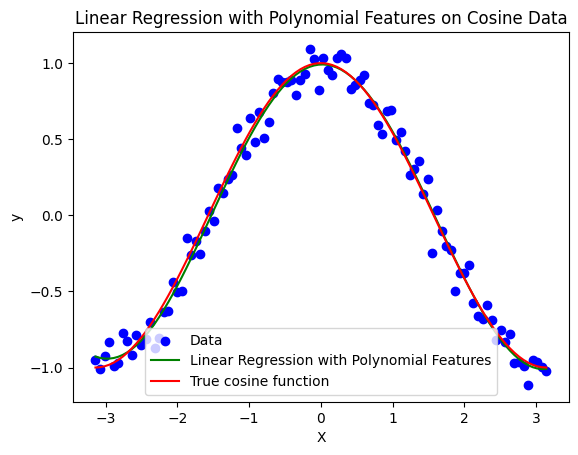

In [27]:
# Fitting Linear Regression with polynomial features
lin_reg_poly = LinearRegression()
lin_reg_poly.fit(X_poly_array, y)

# Making predictions
y_pred_poly = lin_reg_poly.predict(X_poly_array)

# Plotting the results
plt.scatter(x, y, c='b', label="Data")
plt.plot(x, y_pred_poly, c='g', label="Linear Regression with Polynomial Features")
plt.plot(x, np.cos(x), c='r', label="True cosine function")
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression with Polynomial Features on Cosine Data')
plt.legend()
plt.show()

In [28]:
Z = np.sin(x) + np.random.normal(0, 0.1, x.shape)

data_ = pd.DataFrame(data=np.hstack([x, Z, y.reshape(-1,1)]), columns=["X", "Z", "y"])
data_.head()

X_2d = data_[['X', 'Z']].values

poly_transformer_2d = PolynomialFeatures(degree=3)
X_poly_2d = poly_tran.fit_transform(X_2d)




X_2d = data_[['X', 'Z']].values
poly_transformer_2d = PolynomialFeatures(degree=3, interaction_only=True)
X_poly_2d = poly_transformer_2d.fit_transform(X_2d)

# Convert the features into a DataFrame for visualization
df_poly_2d = pd.DataFrame(X_poly_2d)
df_poly_2d['y'] = y

# Displaying the first few rows of the DataFrame with polynomial features
df_poly_2d.head()

,0,1,2,3,y
0,1.0,-3.141593,-0.141537,0.444652,-0.950329
1,1.0,-3.078126,-0.105488,0.324707,-1.011813
2,1.0,-3.014660,-0.160864,0.484950,-0.927186
3,1.0,-2.951193,-0.269479,0.795284,-0.829626
4,1.0,-2.887727,-0.267277,0.771822,-0.991364


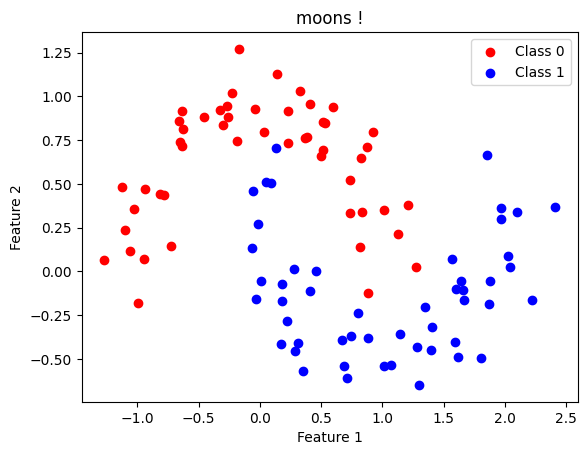

In [47]:
# Polynomial Regression - Classification with scikit learn || بالعربية || Machine Learning #20

from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

X_class, Y_class = make_moons(n_samples=100, noise=0.15, random_state=42)

plt.scatter(X_class[Y_class == 0][:, 0], X_class[Y_class == 0][:, 1], c='red', label='Class 0')
plt.scatter(X_class[Y_class == 1][:, 0], X_class[Y_class == 1][:, 1], c='blue', label='Class 1')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("moons !")
plt.legend(loc='upper right')
plt.show()



In [51]:
from sklearn.preprocessing import PolynomialFeatures


model = PolynomialFeatures(degree=20)

X_poly = model.fit_transform(X_class)

df_poly_class = pd.DataFrame(X_poly, columns=model.get_feature_names_out(['X1', 'X2']))

df_poly_class.head()


,1,X1,X2,X1^2,X1 X2,X2^2,X1^3,X1^2 X2,X1 X2^2,X2^3,X1^4,X1^3 X2,X1^2 X2^2,X1 X2^3,X2^4,X1^5,X1^4 X2,X1^3 X2^2,X1^2 X2^3,X1 X2^4,X2^5,X1^6,X1^5 X2,X1^4 X2^2,X1^3 X2^3,X1^2 X2^4,X1 X2^5,X2^6,X1^7,X1^6 X2,X1^5 X2^2,X1^4 X2^3,X1^3 X2^4,X1^2 X2^5,X1 X2^6,X2^7,X1^8,X1^7 X2,X1^6 X2^2,X1^5 X2^3,...,X1^18 X2,X1^17 X2^2,X1^16 X2^3,X1^15 X2^4,X1^14 X2^5,X1^13 X2^6,X1^12 X2^7,X1^11 X2^8,X1^10 X2^9,X1^9 X2^10,X1^8 X2^11,X1^7 X2^12,X1^6 X2^13,X1^5 X2^14,X1^4 X2^15,X1^3 X2^16,X1^2 X2^17,X1 X2^18,X2^19,X1^20,X1^19 X2,X1^18 X2^2,X1^17 X2^3,X1^16 X2^4,X1^15 X2^5,X1^14 X2^6,X1^13 X2^7,X1^12 X2^8,X1^11 X2^9,X1^10 X2^10,X1^9 X2^11,X1^8 X2^12,X1^7 X2^13,X1^6 X2^14,X1^5 X2^15,X1^4 X2^16,X1^3 X2^17,X1^2 X2^18,X1 X2^19,X2^20
0,1.0,1.613838,-0.491151,2.604474,-0.792638,0.241229,4.203200,-1.279190,0.389305,-0.118480,6.783286,-2.064405,0.628275,-0.191207,0.058192,10.947127,-3.331617,1.013935,-0.308578,0.093912,-0.028581,1.766689e+01,-5.376691,1.636326,-0.497995,0.151558,-0.046125,0.014037,2.851151e+01,-8.677109e+00,2.640766,-0.803683,0.244591,-0.074438,0.022654,-0.006895,4.601296e+01,-1.400345e+01,4.261770e+00,-1.297015e+00,...,-2.708291e+03,8.242335e+02,-2.508448e+02,7.634139e+01,-2.323352e+01,7.070821e+00,-2.151913e+00,6.549069e-01,-1.993125e-01,6.065818e-02,-1.846053e-02,5.618225e-03,-1.709834e-03,5.203660e-04,-1.583667e-04,4.819685e-05,-1.466809e-05,4.464044e-06,-1.358574e-06,1.436152e+04,-4.370745e+03,1.330180e+03,-4.048230e+02,1.232027e+02,-3.749514e+01,1.141116e+01,-3.472840e+00,1.056914e+00,-3.216581e-01,9.789249e-02,-2.979232e-02,9.066907e-03,-2.759396e-03,8.397866e-04,-2.555782e-04,7.778193e-05,-2.367193e-05,7.204245e-06,-2.192519e-06,6.672648e-07
1,1.0,0.089847,0.504391,0.008073,0.045318,0.254410,0.000725,0.004072,0.022858,0.128322,0.000065,0.000366,0.002054,0.011529,0.064724,0.000006,0.000033,0.000185,0.001036,0.005815,0.032646,5.260514e-07,0.000003,0.000017,0.000093,0.000522,0.002933,0.016467,4.726426e-08,2.653354e-07,0.000001,0.000008,0.000047,0.000264,0.001479,0.008306,4.246563e-09,2.383965e-08,1.338327e-07,7.513189e-07,...,7.342628e-20,4.122055e-19,2.314067e-18,1.299087e-17,7.292904e-17,4.094141e-16,2.298397e-15,1.290290e-14,7.243518e-14,4.066416e-13,2.282832e-12,1.281552e-11,7.194466e-11,4.038879e-10,2.267373e-09,1.272874e-08,7.145746e-08,4.011528e-07,2.252019e-06,1.175152e-21,6.597148e-21,3.703552e-20,2.079126e-19,1.167194e-18,6.552473e-18,3.678472e-17,2.065046e-16,1.159290e-15,6.508100e-15,3.653562e-14,2.051062e-13,1.151439e-12,6.464028e-12,3.628821e-11,2.037172e-10,1.143642e-09,6.420255e-09,3.604247e-08,2.023377e-07,1.135897e-06
2,1.0,0.747210,-0.369111,0.558323,-0.275804,0.136243,0.417185,-0.206083,0.101802,-0.050289,0.311725,-0.153988,0.076068,-0.037576,0.018562,0.232924,-0.115061,0.056839,-0.028077,0.013870,-0.006852,1.740434e-01,-0.085975,0.042470,-0.020980,0.010364,-0.005120,0.002529,1.300471e-01,-6.424138e-02,0.031734,-0.015676,0.007744,-0.003825,0.001890,-0.000933,9.717254e-02,-4.800183e-02,2.371221e-02,-1.171349e-02,...,-1.945943e-03,9.612679e-04,-4.748524e-04,2.345702e-04,-1.158743e-04,5.724022e-05,-2.827584e-05,1.396786e-05,-6.899919e-06,3.408460e-06,-1.683730e-06,8.317383e-07,-4.108667e-07,2.029622e-07,-1.002604e-07,4.952718e-08,-2.446571e-08,1.208571e-08,-5.970164e-09,2.943465e-03,-1.454029e-03,7.182694e-04,-3.548147e-04,1.752733e-04,-8.658248e-05,4.277049e-05,-2.112801e-05,1.043693e-05,-5.155692e-06,2.546837e-06,-1.258101e-06,6.214835e-07,-3.070039e-07,1.516555e-07,-7.491561e-08,3.700723e-08,-1.828103e-08,9.030566e-09,-4.460969e-09,2.203654e-09
3,1.0,-1.101745,0.236856,1.213842,-0.260955,0.056101,-1.337345,0.287506,-0.061809,0.013288,1.473413,-0.316759,0.068098,-0.014640,0.003147,-1.623326,0.348987,-0.075026,0.016129,-0.003468,0.000745,1.788491e+00,-0.384495,0.082660,-0.017770,0.003820,-0.000821,0.000177,-1.970462e+00,4.236157e-01,-0.091070,0.019579,-0.004209,0.000905,-0.000195,0.000042,2.170947e+00,-4.667165e-01,1.003361e-01,-2.157055e-02,...,1.355020e+00,-2.913062e-01,6.262586e-02,-1.346349e-02,2.894421e-03,-6.222512e-0

In [52]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X_poly, Y_class)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

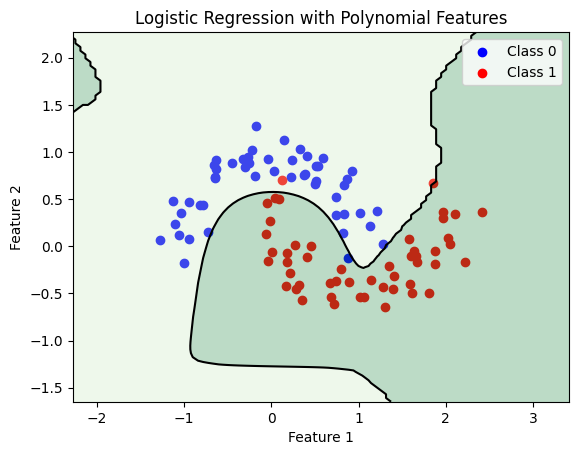

In [53]:
# Plotting the decision boundary
x1_min, x1_max = X_class[:, 0].min() - 1, X_class[:, 0].max() + 1
x2_min, x2_max = X_class[:, 1].min() - 1, X_class[:, 1].max() + 1

xx1, xx2 = np.meshgrid(np.linspace(x1_min, x1_max, 100), np.linspace(x2_min, x2_max, 100))
X_grid = np.c_[xx1.ravel(), xx2.ravel()]
X_grid_poly = model.transform(X_grid)
probs = log_reg.predict_proba(X_grid_poly)[:, 1].reshape(xx1.shape)

plt.scatter(X_class[Y_class == 0][:, 0], X_class[Y_class == 0][:, 1], c='b', label='Class 0')
plt.scatter(X_class[Y_class == 1][:, 0], X_class[Y_class == 1][:, 1], c='r', label='Class 1')
plt.contourf(xx1, xx2, probs, levels=[0, 0.5, 1], alpha=0.3, cmap='Greens')
plt.contour(xx1, xx2, probs, levels=[0.5], colors='black')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression with Polynomial Features')
plt.legend()
plt.show()